<a href="https://colab.research.google.com/github/pydevcasts/MLHub/blob/master/Language_Translation_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.models import Model
from tensorflow.keras import models
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input,LSTM,Dense
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pickle

In [2]:
#initialize all variables
input_texts=[]
target_texts=[]
input_characters=set()
target_characters=set()


In [3]:
#read dataset file
from google.colab import files

uploaded = files.upload()


Saving eng-french.txt to eng-french.txt


In [4]:
#read dataset file
with open('eng-french.txt','r',encoding='utf-8') as f:
    rows=f.read().split('\n')
for row in rows[:1000]:
  input_text, target_text = row.split('\t')
  #add '\t' at start and '\n' at end of text.
  target_text='\t' + target_text + '\n'
  input_texts.append(input_text.lower())
  target_texts.append(target_text.lower())
  input_characters.update(list(input_text.lower()))
  target_characters.update(list(target_text.lower()))

In [5]:
input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))

num_en_chars = len(input_characters)
num_dec_chars = len(target_characters)

max_input_length = max([len(i) for i in input_texts])
max_target_length = max([len(i) for i in target_texts])

print("number of encoder characters : ",num_en_chars)
print("number of decoder characters : ",num_dec_chars)

print("maximum input length : ",max_input_length)
print("maximum target length : ",max_target_length)

number of encoder characters :  40
number of decoder characters :  52
maximum input length :  11
maximum target length :  33


In [18]:
def bagofcharacters(input_texts,target_texts):

    #initialize encoder , decoder input and target data.
    en_in_data=[]
    dec_in_data=[]
    dec_tr_data=[]

    #padding variable with first character as 1 as rest all 0.
    pad_en=[1]+[0]*(len(input_characters)-1)
    pad_dec=[0]*(len(target_characters))
    pad_dec[2]=1

    #countvectorizer for one hot encoding as we want to tokenize character so
    #analyzer is true and None the stopwords action.
    cv=CountVectorizer(binary=True,tokenizer=lambda txt:
    txt.split(),stop_words=None,analyzer='char')

    for i,(input_t,target_t) in enumerate(zip(input_texts,target_texts)):
        #fit the input characters into the CountVectorizer function
        cv_inp= cv.fit(input_characters)

        #transform the input text from the help of CountVectorizer fit.
        #it character present than put 1 and 0 otherwise.
        en_in_data.append(cv_inp.transform(list(input_t)).toarray().tolist())
        cv_tar= cv.fit(target_characters)
        dec_in_data.append(cv_tar.transform(list(target_t)).toarray().tolist())

        #decoder target will be one timestep ahead because it will not consider
        #the first character i.e. '\t'.
        dec_tr_data.append(cv_tar.transform(list(target_t)[1:]).toarray().tolist())


         #add padding variable if the length of the input or target text is smaller
        #than their respective maximum input or target length.
        if len(input_t) < max_input_length:
          for _ in range(max_input_length-len(input_t)):
            en_in_data[i].append(pad_en)
        if len(target_t) < max_target_length:
          for _ in range(max_target_length-len(target_t)):
            dec_in_data[i].append(pad_dec)
        if (len(target_t)-1) < max_target_length:
          for _ in range(max_target_length-len(target_t)+1):
            dec_tr_data[i].append(pad_dec)

    #convert list to numpy array with data type float32
    en_in_data=np.array(en_in_data,dtype="float32")
    dec_in_data=np.array(dec_in_data,dtype="float32")
    dec_tr_data=np.array(dec_tr_data,dtype="float32")

    return en_in_data,dec_in_data,dec_tr_data


In [19]:

#create input object of total number of encoder characters
en_inputs = Input(shape=(None, num_en_chars))
#create LSTM with the hidden dimension of 256
#return state=True as we don't want output sequence.
encoder = LSTM(256, return_state=True)
#discard encoder output and store hidden and cell state.
en_outputs, state_h, state_c = encoder(en_inputs)
en_states = [state_h, state_c]

#create input object of total number of decoder characters
dec_inputs = Input(shape=(None, num_dec_chars))
#create LSTM with the hidden dimension of 256
#return state and return sequences as we want output sequence.
dec_lstm = LSTM(256, return_sequences=True, return_state=True)
#initialize the decoder model with the states on encoder.
dec_outputs, _, _ = dec_lstm(dec_inputs, initial_state=en_states)
#Output layer with shape of total number of decoder characters
dec_dense = Dense(num_dec_chars, activation="softmax")
dec_outputs = dec_dense(dec_outputs)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9817 - loss: 0.0334 - val_accuracy: 0.7233 - val_loss: 2.0001
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9832 - loss: 0.0311 - val_accuracy: 0.7332 - val_loss: 1.9406
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9834 - loss: 0.0294 - val_accuracy: 0.7308 - val_loss: 1.9431
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9832 - loss: 0.0290 - val_accuracy: 0.7305 - val_loss: 1.9580
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9829 - loss: 0.0287 - val_accuracy: 0.7306 - val_loss: 1.9383
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9822 - loss: 0.0299 - val_accuracy: 0.7288 - val_loss: 1.9658
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.0282 - val_accuracy: 0.7291 - val_loss: 1.9530
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9837 - loss: 0.0270 - val_accuracy: 0.

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None, 40)       │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, None, 52)       │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 256), (None,   │        304,128 │ input_layer[0][0]      │
│                           │ 256), (None, 256)]     │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, None, 256),    │        316,416 │ input_layer_1[0][0],   │
│                           │ (None, 256), (None,    │                │ lstm[0][1], lstm[0][2] │
│                           │ 256)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 52)       │         13,364 │ lstm_1[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,901,726 (7.25 MB)

 Trainable params: 633,908 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,267,818 (4.84 MB)

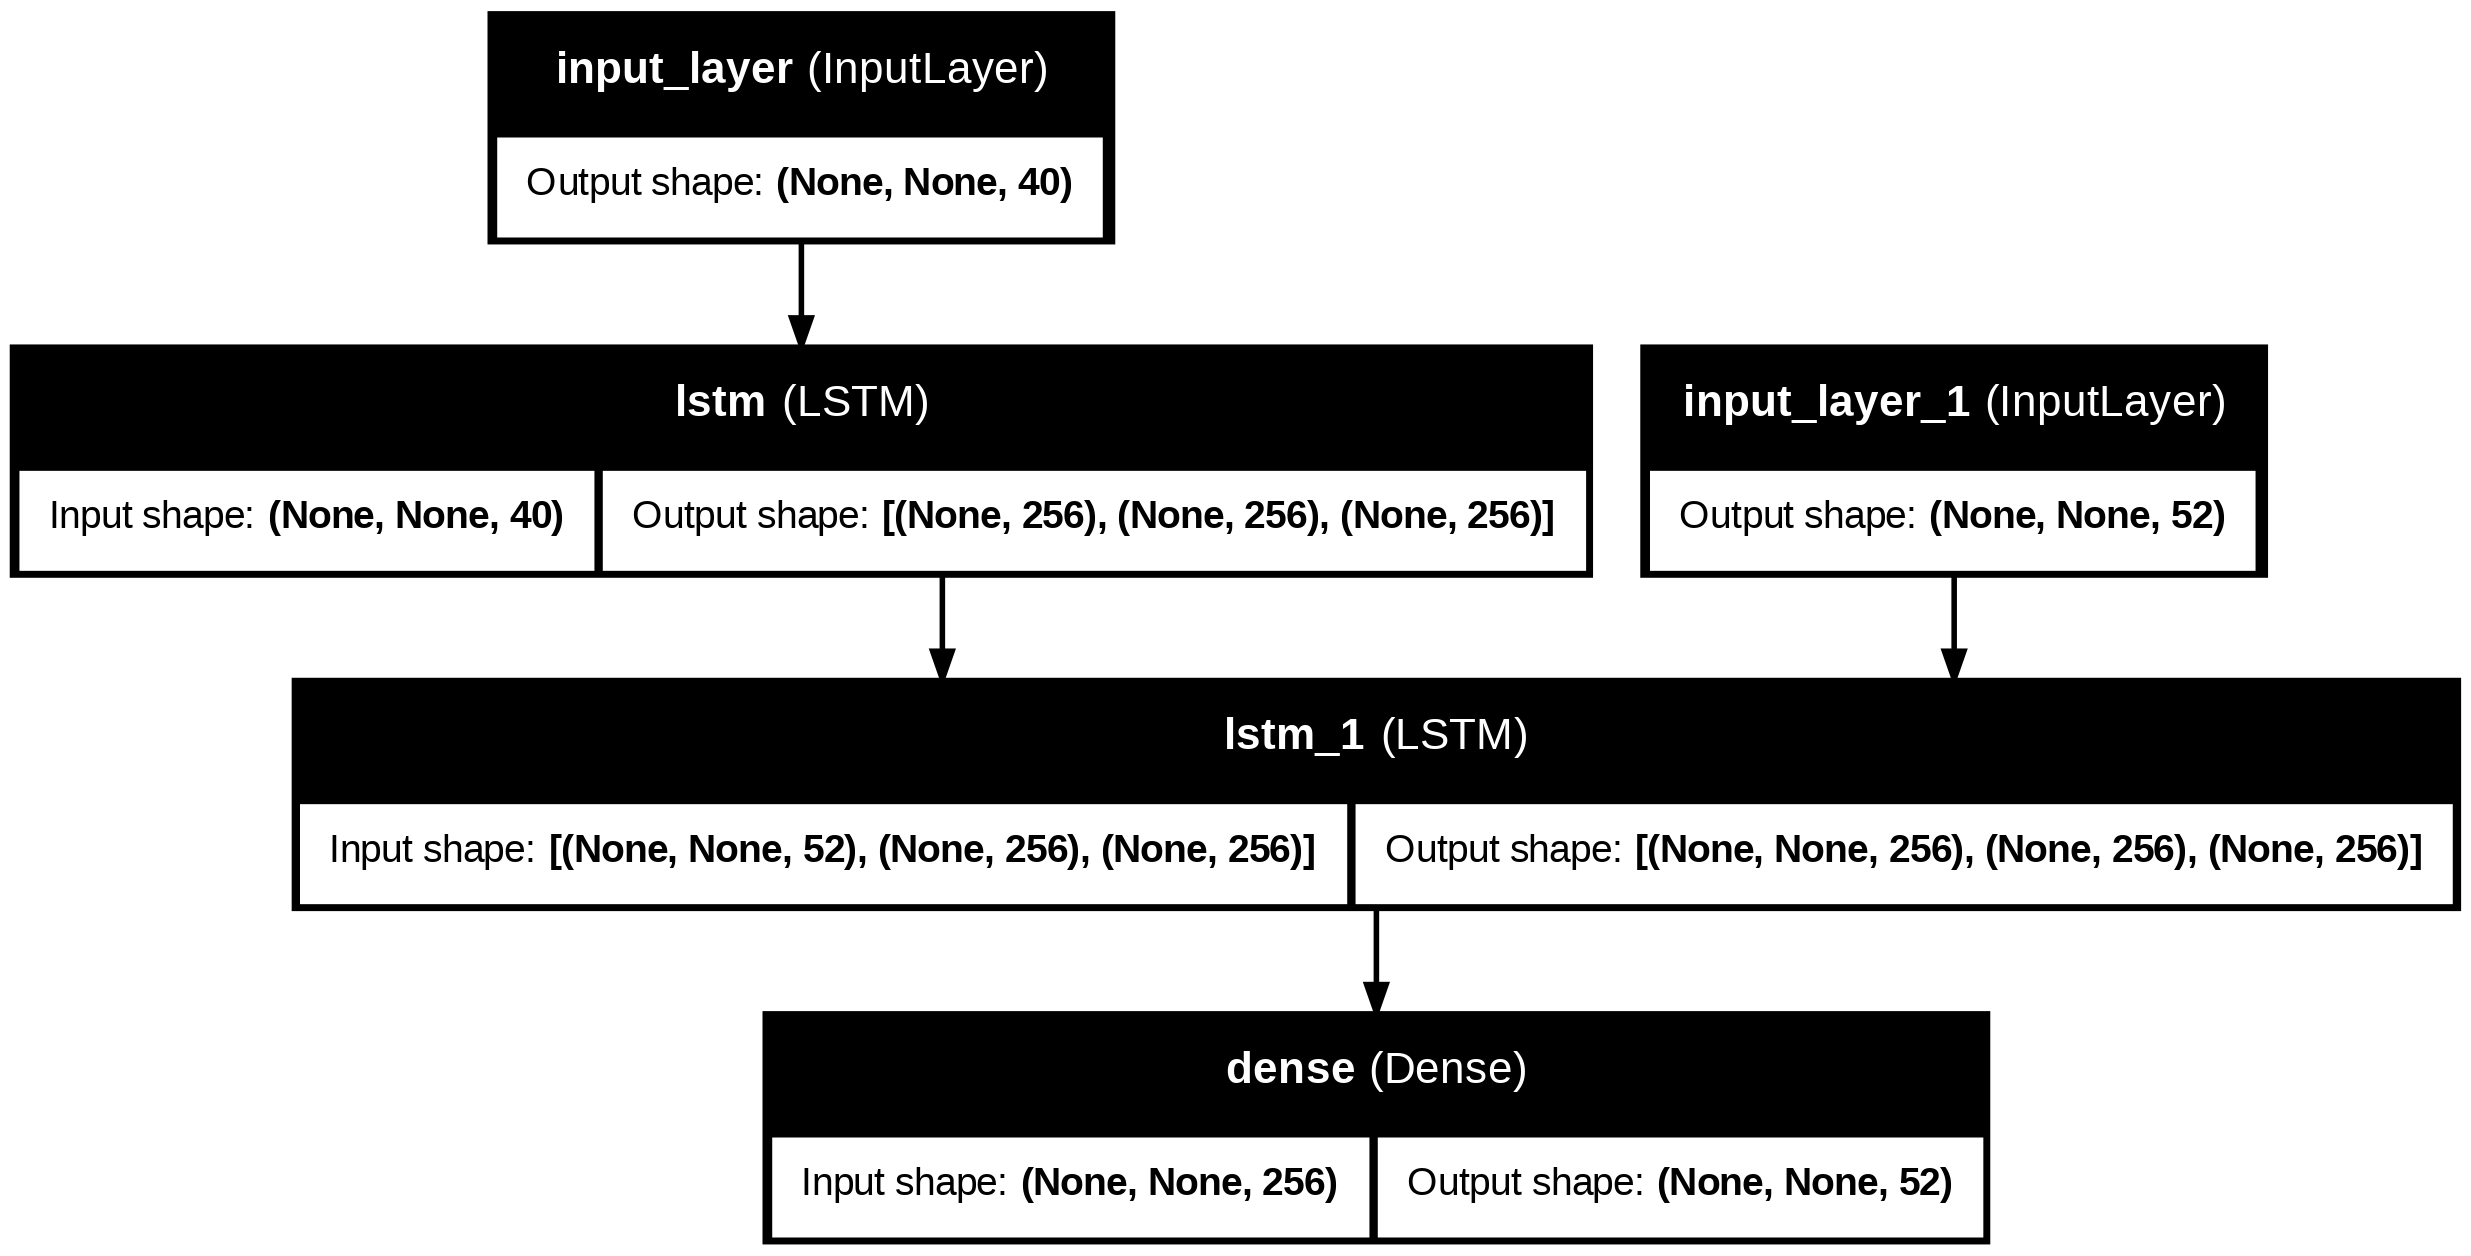

In [23]:

#create Model and store all variables
model = Model([en_inputs, dec_inputs], dec_outputs)
pickle.dump({'input_characters':input_characters,'target_characters':target_characters,
             'max_input_length':max_input_length,'max_target_length':max_target_length,
             'num_en_chars':num_en_chars,'num_dec_chars':num_dec_chars},open("training_data.pkl","wb"))

#load the data and train the model
en_in_data,dec_in_data,dec_tr_data = bagofcharacters(input_texts,target_texts)
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model.fit(
    [en_in_data, dec_in_data],
    dec_tr_data,
    batch_size=64,
    epochs=200,
    validation_split=0.2,
)

model.save("s2s.h5")

#summary and model plot
model.summary()
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [63]:
!pip install PyQt6


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.6/284.6 kB 29.8 MB/s eta 0:00:00


In [ ]:
import sys
import pickle
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Model
from tensorflow.keras import models
from tensorflow.keras.layers import Input, LSTM, Dense
from PyQt6.QtWidgets import QApplication, QWidget, QVBoxLayout, QLabel, QTextEdit, QLineEdit, QPushButton, QScrollArea

BG_COLOR = "#000"
TEXT_COLOR = "#FFF"
FONT = "Helvetica 14"
FONT_BOLD = "Helvetica 13 bold"

cv = CountVectorizer(binary=True, tokenizer=lambda txt: txt.split(), stop_words=None, analyzer='char')

class LangTRans(QWidget):
    def __init__(self):
        super().__init__()
        self.initUI()
        self.datafile()

    def initUI(self):
        # Set up the main window
        self.setWindowTitle("Language Translator")
        self.setFixedSize(520, 520)
        self.setStyleSheet(f"background-color: {BG_COLOR}; color: {TEXT_COLOR};")

        layout = QVBoxLayout()

        # Header Label
        head_label = QLabel("Welcome to DataFlair", self)
        head_label.setStyleSheet(f"font: {FONT_BOLD}; padding: 10px;")
        layout.addWidget(head_label)

        # Text widget for input and output
        self.text_widget = QTextEdit(self)
        self.text_widget.setStyleSheet("background-color: #fff; color: #000;")
        self.text_widget.setReadOnly(True)
        layout.addWidget(self.text_widget)

        # Input field
        self.msg_entry = QLineEdit(self)
        self.msg_entry.setStyleSheet("background-color: #2C3E50; color: #FFF;")
        layout.addWidget(self.msg_entry)

        # Send button
        send_button = QPushButton("Send", self)
        send_button.setStyleSheet(f"font: {FONT_BOLD};")
        send_button.clicked.connect(self.on_enter)
        layout.addWidget(send_button)

        self.setLayout(layout)

    def datafile(self):
        # Load data from the file
        datafile = pickle.load(open("training_data.pkl", "rb"))
        self.input_characters = datafile['input_characters']
        self.target_characters = datafile['target_characters']
        self.max_input_length = datafile['max_input_length']
        self.max_target_length = datafile['max_target_length']
        self.num_en_chars = datafile['num_en_chars']
        self.num_dec_chars = datafile['num_dec_chars']
        self.loadmodel()

    def loadmodel(self):
        # Load the model
        model = models.load_model("s2s.h5")
        enc_outputs, state_h_enc, state_c_enc = model.layers[2].output  # lstm_1
        self.en_model = Model(model.input[0], [state_h_enc, state_c_enc])

        dec_state_input_h = Input(shape=(256,), name="input_3")
        dec_state_input_c = Input(shape=(256,), name="input_4")
        dec_states_inputs = [dec_state_input_h, dec_state_input_c]

        dec_lstm = model.layers[3]
        dec_outputs, state_h_dec, state_c_dec = dec_lstm(model.input[1], initial_state=dec_states_inputs)
        dec_dense = model.layers[4]
        dec_outputs = dec_dense(dec_outputs)

        self.dec_model = Model([model.input[1]] + dec_states_inputs, [dec_outputs] + [state_h_dec, state_c_dec])

    def decode_sequence(self, input_seq):
        reverse_target_char_index = dict(enumerate(self.target_characters))
        states_value = self.en_model.predict(input_seq)

        co = cv.fit(self.target_characters)
        target_seq = np.array([co.transform(list("\t")).toarray().tolist()], dtype="float32")

        stop_condition = False
        decoded_sentence = ""
        while not stop_condition:
            output_chars, h, c = self.dec_model.predict([target_seq] + states_value)

            char_index = np.argmax(output_chars[0, -1, :])
            text_char = reverse_target_char_index[char_index]
            decoded_sentence += text_char

            if text_char == "\n" or len(decoded_sentence) > self.max_target_length:
                stop_condition = True

            target_seq = np.zeros((1, 1, self.num_dec_chars))
            target_seq[0, 0, char_index] = 1.0
            states_value = [h, c]
        return decoded_sentence

    def on_enter(self):
        msg = self.msg_entry.text()
        self.my_msg(msg, "English")
        self.deocded_output(msg, "Decoded")

    def bagofcharacters(self, input_t):
        cv = CountVectorizer(binary=True, tokenizer=lambda txt: txt.split(), stop_words=None, analyzer='char')
        en_in_data = []
        pad_en = [1] + [0] * (len(self.input_characters) - 1)

        cv_inp = cv.fit(self.input_characters)
        en_in_data.append(cv_inp.transform(list(input_t)).toarray().tolist())

        if len(input_t) < self.max_input_length:
            for _ in range(self.max_input_length - len(input_t)):
                en_in_data[0].append(pad_en)

        return np.array(en_in_data, dtype="float32")

    def deocded_output(self, msg, sender):
        en_in_data = self.bagofcharacters(msg.lower() + ".")
        decoded_sentence = self.decode_sequence(en_in_data)
        self.text_widget.append(f"{sender} : {decoded_sentence}\n")

    def my_msg(self, msg, sender):
        if not msg:
            return
        self.msg_entry.clear()
        self.text_widget.append(f"{sender} : {msg}\n")

if __name__ == "__main__":
    app = QApplication(sys.argv)
    translator = LangTRans()
    translator.show()
    # sys.exit(app.exec())

